In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
image_path = "../../output_videos/tracked_video_frame_1.jpg"
image  = cv2.imread(image_path)
image= cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

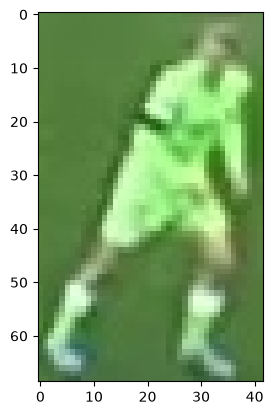

In [3]:
plt.imshow(image)
plt.show()

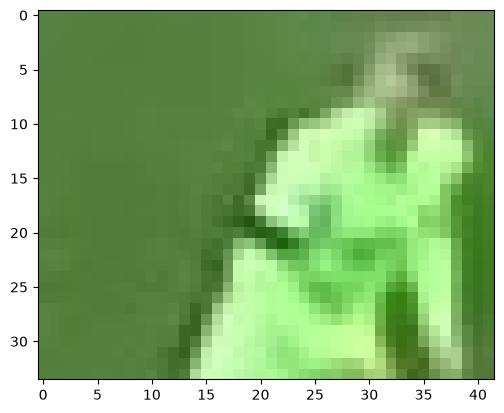

In [4]:
top_half_image = image[0: int(image.shape[0]/2), :]
plt.imshow(top_half_image)
plt.show()

In [5]:
#Cluster the image into two clusters
#Reshape the image into 2D array
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


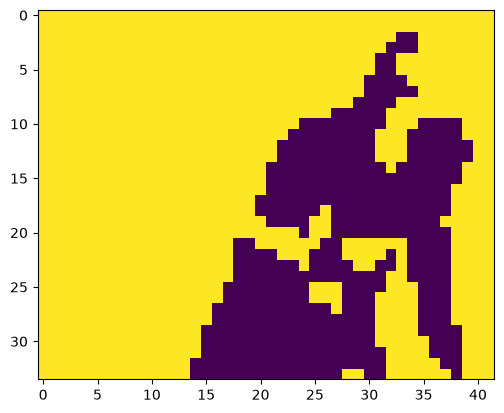

In [11]:
from sklearn.cluster import KMeans
image_2D = top_half_image.reshape(-1,3)
kMeans = KMeans(n_clusters=2, random_state=0)
kMeans.fit(image_2D)
#Get the cluster labels
labels = kMeans.labels_
#reshape the labels into the original image shape
clustered_image = labels.reshape(top_half_image.shape[0],top_half_image.shape[1])
#Display the clustered image
plt.imshow(clustered_image)

In [12]:
corner_clusters = [clustered_image[0,0], clustered_image[0,-1], clustered_image[-1,0],clustered_image[-1,-1]]
non_player_cluster = max(set(corner_clusters),key=corner_clusters.count)
print(non_player_cluster)

1


In [13]:
player_cluster = 1-non_player_cluster
print(player_cluster)

0


In [14]:
kMeans.cluster_centers_[player_cluster]

array([168.72087379, 232.59708738, 143.01213592])